<table>
 <tr align=left><td><img align=left src="https://i.creativecommons.org/l/by/4.0/88x31.png">
 <td>Text provided under a Creative Commons Attribution license, CC-BY. All code is made available under the FSF-approved MIT license. (c) Kyle T. Mandli (and Marc Spiegelman)</td>
</table>

Sebagian besar materi ini diadaptasi dari beberapa bab pertama [Larson dan Bengzon: Metode Elemen Hingga
Teori, Implementasi,
dan Aplikasi](http://link.springer.com/book/10.1007%2F978-3-642-33287-6).

In [ ]:
%matplotlib inline  # Mengaktifkan plotting inline di Jupyter notebook agar plot ditampilkan langsung di bawah sel kode
import numpy  # Mengimpor library NumPy untuk operasi array dan komputasi numerik
import matplotlib.pyplot as plt  # Mengimpor modul pyplot dari Matplotlib untuk membuat plot dan visualisasi data

<div style="text-align: justify; font-family: 'Times New Roman', Times, serif;">

# Metode Finite Element: Pengenalan

Metode Elemen Hingga (MEH) memberikan cara lain untuk mengubah PDE (Persamaan Diferensial Parsial) kontinyu menjadi sistem persamaan linear dan non-linear diskret, dan sangat populer dalam bidang Teknik dan Mekanika Solid (meskipun metodenya sepenuhnya umum). Elemen Hingga memiliki dasar matematika yang kaya dalam analisis fungsional serta berbagai aplikasi khusus. Singkatnya, subjek ini dan literaturnya sangat luas. Tujuan catatan ini hanyalah memberikan pengenalan dasar tentang beberapa ide fundamental dalam Elemen Hingga dan implementasinya.
</div>

<div style="text-align: justify; font-family: 'Times New Roman', Times, serif;">

## Ruang Fungsi Finite Element

Ide kunci dalam Elemen Hingga adalah kita akan mendekati fungsi kontinyu $f(x)$ sebagai kombinasi linear dari sejumlah terbatas fungsi basis

$$
    f_h(x) = \sum_{i=0}^N w_i \phi_i(x)
$$

dengan $\phi_i(x)$ adalah fungsi basis dan $w_i$ adalah serangkaian bobot. Kami telah melihat dekomposisi serupa untuk metode spektral. Namun daripada menggunakan fungsi basis global seperti $\sin(kx)$ atau polinomial Chebyshev, kami akan (sebagian besar) menggunakan polinomial piecewise (per-bagian).

</div>


### Piecewise Linear Functions in 1-D (P1)

![](./images/P1_function_annotated_fig1.1LB.png)

Sebagai contoh, perhatikan fungsi "hubungkan titik-titik" linear per-segmen yang digambarkan di atas di mana kita telah menguraikan interval $I=[x_0,x_5]$ menjadi 5 sub-interval atau "elemen" $e_i = [x_{i},x_{i+1}]$ dengan $i=1\ldots 4$. Di atas setiap interval ini, fungsi $v_h$ adalah fungsi linear dari $x$ dan setiap segmen berkelanjutan di tepi elemen. Gambar dimodifikasi dari Gambar 1.1 dari Larson dan Bengzon.  

Meskipun $v_h(x)$ adalah fungsi berkelanjutan yang dapat dievaluasi untuk nilai $x$ apa pun, harus jelas bahwa benar-benar hanya ada 6 derajat kebebasan yang sesuai dengan nilai pada node $\vec v = [v_0,v_1,v_2,v_3,\ldots,v_5]$. Hanya dengan mengubah 6 angka ini, kita dapat menghasilkan jumlah tak terbatas fungsi linear per-segmen pada triangulasi ini. Kami akan menyebut ruang fungsi berdimensi hingga ini $\cal V_h$, yang sepenuhnya dijelaskan oleh mesh elemen dan interpolant di atas setiap elemen.  

<div style="text-align: justify; font-family: 'Times New Roman', Times, serif;">


### Fungsi Basis Global

Diberikan ruang fungsi diskret apa pun $\cal V_h$, kami harus dapat mendeskripsikan fungsi apa pun $v_h\in \cal V_h$ dalam hal serangkaian fungsi basis yang mencakup ruang. Dalam kasus ruang fungsi linear per-segmen 1-D, fungsi basis global diberikan oleh "Fungsi Topi"

$$
\phi_i(x) = \left\{
\begin{array}{ll}
(x - x_{i-1})/\Delta x_{i-1}, & x\in e_{i-1} \\
(x_i - x)/\Delta x_{i}, & x\in e_{i} \\
0, & \text{sebaliknya} \\
\end{array}
\right.
$$

<div style="text-align: justify; font-family: 'Times New Roman', Times, serif;">

Yang memiliki sifat penting bahwa $\phi_i(x_j) = \delta_{ij}$. Fungsi topi tipikal ditunjukkan di Gambar 1.2 dari Larson dan Bengson.
![](./images/P1_Hat_function_fig1.2LB.png)

Meskipun tidak sepenuhnya jelas, kami dapat membangun semua fungsi linear per-segmen dalam $\cal V_h$ sebagai kombinasi linear dari fungsi topi ini, yaitu

$$
f_h(x) = \sum_{i=0}^5 w_i\phi_i(x)
$$

<div style="text-align: justify; font-family: 'Times New Roman', Times, serif;">

### Fungsi Basis Lokal

Untuk memperjelas ini sedikit, perlu dilihat bagaimana fungsi basis ini menginterpolasi $v$ atas satu elemen.

![](./images/P1LocalBases.png)

> **Gambar *3*: Definisi Fungsi Basis Global dan Lokal**

<div style="text-align: justify; font-family: 'Times New Roman', Times, serif;">

Pertimbangkan hanya bagian dari $v(x)$ yang terletak dalam elemen $e_i$. Jelas bahwa hanya fungsi basis global yang memiliki dukungan dalam elemen $e_i$ adalah $\phi_i(x)$ dan $\phi_{i+1}(x)$. Kami klaim bahwa atas elemen ini
$$
v(x) = v_i\phi_i(x) + v_{i+1}\phi_{i+1}(x)\quad\text{untuk}\quad x\in [x_i,x_{i+1}]
$$

Ini jelas benar di node karena sifat bahwa $\phi_i(x_j) = \delta_{ij}$.  

<div style="text-align: justify; font-family: 'Times New Roman', Times, serif;">

Di antara node, kami mengharapkan bahwa $\phi_i$ dan $\phi_{i+1}$ memberikan interpolasi linear. Jika kami hanya mempertimbangkan *fungsi basis lokal* yang merupakan bagian dari $\phi_i$ dan $\phi_{i+1}$ dalam elemen $e_i$

\begin{align}
  N_0(x) & = (x_{i+1} - x)/(x_{i+1} - x_i)\\
  N_1(x) & = (x - x_i)/(x_{i+1} - x_i)\\
\end{align}

menjadi jelas bahwa ini hanyalah Polinomial Lagrange orde 1 yang menginterpolasi fungsi linear apa pun atas interval $[x_i,x_{i+1}]$. Hanya untuk memeriksa, perhatikan bahwa jika $x* = x_i + t \Delta x_i$ dengan $s$ adalah jarak fraksional di seluruh elemen dengan panjang $\Delta x_i = x_{i+1} - x_i$, maka
\begin{align}
  N_0(x*) & = (x_{i+1} - x_i -s \Delta x_i)/\Delta x_i = (1 - s)\\
  N_1(x*) & = (x_i + s \Delta x_i - x_i)/\Delta x_i = s\\
\end{align}

sehingga dalam $e_i$
$$
   v(x) = v_i N_0(x) + v_{i+1}N_1(x) = v_i(1 - s)  + v_{i+1} s
$$
dengan $s\in[0,1]$

Jadi fungsi penuh kami $v(x)$ di atas domain penuh $\Omega = [x_0,x_5]$ hanyalah gabungan potongan linear lokal ini. Sepanjang pengenalan ini, kami akan sering bergerak antara pandangan global dan pandangan elemen tergantung pada kerangka referensi mana yang lebih nyaman.

<div style="text-align: justify; font-family: 'Times New Roman', Times, serif;">

### Ruang Fungsi Polinomial Orde Tinggi

Ruang fungsi linear per-segmen sering disebut sebagai $P_1$ tetapi ada pilihan lain. Misalnya, ruang fungsi kuadratik per-segmen ($P_2$) memiliki serangkaian fungsi basis lokal yang hanya merupakan Polinomial Lagrange orde 2 dan memerlukan tiga derajat kebebasan per node. Fungsi basis global hanya dibangun dari yang lokal. Gambar menunjukkan subset fungsi basis untuk $P_2$ yang berbeda untuk derajat kebebasan di pusat dan tepi elemen (gambar asli dari [Pengenalan Metode Elemen Hingga](http://hplgit.github.io/INF5620/doc/pub/sphinx-fem)

![](http://hplgit.github.io/INF5620/doc/pub/sphinx-fem/_images/mpl_fe_basis_p2_4e_lab.png)



<div style="text-align: justify; font-family: 'Times New Roman', Times, serif;">

## Interpolasi fungsi $f(x)$ ke $\cal V$

Diberikan serangkaian fungsi basis $\phi_i(x)$ untuk ruang fungsi $\cal V$, harus jelas bahwa tidak semua fungsi dapat direpresentasikan dengan tepat, tanpa kesalahan di $\cal V$. Misalnya, diberi fungsi mulus $f(x)$, pertanyaan muncul tentang bagaimana membangun pendekatan $f_h(x) \in \cal V$ yang meminimalkan beberapa ukuran kesalahan. Sebenarnya ada beberapa pendekatan. Pendekatan paling sederhana adalah *interpolasi* atau *proyeksi* dari $f$ ke $\cal V$, yang akan kami nyatakan sebagai $\pi f$, dan tentukan sebagai fungsi $\pi f \in \cal V$ sedemikian rupa sehingga

$$
    \pi f (x) = \sum_{i=0}^N f(x_i)\phi(x)
$$

<div style="text-align: justify; font-family: 'Times New Roman', Times, serif;">

Mengingat sifat interpolasi dari polinomial Lagrange, harus jelas bahwa

$$
\pi f(x_j) = f(x_j)
$$

yaitu kedua fungsi memiliki kesalahan nol pada derajat kebebasan. 

<div style="text-align: justify; font-family: 'Times New Roman', Times, serif;">

Figure 1.3 from Larson and Bengzon shows the linear interpolant of a function $f$ onto a single element over the interval $[x_0,x_1]$.
![](./images/f_interpolation_P1_01.png)

<div style="text-align: justify; font-family: 'Times New Roman', Times, serif;">

Gambar 1.4 dari Larson dan Bengzon menunjukkan interpolant linear dari fungsi $f$ ke ruang fungsi linear per-segmen $\cal V$.

![](./images/f_interpolation_P1_02.png)

<div style="text-align: justify; font-family: 'Times New Roman', Times, serif;">

### Kesalahan Interpolasi

Secara umum biasanya akan ada kesalahan antara $f(x)$ dan interpolantnya $\pi f(x)$. Untuk mengukur kesalahan ini biasanya memerlukan pendefinisian beberapa norm dan seperti biasanya ada banyak pilihan. Namun ternyata, norm yang berguna dalam elemen hingga adalah norm $L^2$ dari fungsi di atas domain $\Omega$

$$
    ||f||_{L^2} = \left[ \int_\Omega f^2 dx\right]^{1/2}
$$

dan normnya yang terkait

$$
    ||f||_{L^2(I)} = \left[ \int_I f^2 dx\right]^{1/2}
$$

di atas sub-interval $I$ (biasanya elemen).

<div style="text-align: justify; font-family: 'Times New Roman', Times, serif;">

Mengingat definisi ini dan perilaku interpolasi polinomial, relatif mudah untuk membuat perkiraan berikut kesalahan interpolasi

* Kesalahan interpolasi atas elemen linear P1 tunggal
$$ 
|| f - \pi f||_{L^2(I)} \leq C \Delta x^2||f''||_{L^2(I)}
$$
di mana $I = [x_i,x{i+1}]$, $\Delta x = x_{i+1} - x_{i}$, C adalah konstanta, dan $||f''||_{L^2(I)}$ adalah ukuran kelengkungan fungsi di atas interval. Jika $\Delta x=0$ atau fungsi linear atas interval, maka kesalahannya nol.

* Kesalahan interpolasi di seluruh domain
Untuk fungsi polinomial per-segmen, kesalahan dalam interpolant ke $\cal V$ hanya penjumlahan kesalahan atas elemen, yaitu
$$ 
|| f - \pi f||^2_{L^2} \leq C \sum_{i=0}^N \Delta x_i^4||f''||^2_{L^2(I_i)}
$$

<div style="text-align: justify; font-family: 'Times New Roman', Times, serif;">

### Konvergensi

Mengingat perkiraan kesalahan ini, jelas bahwa interpolant konvergen ke fungsi kontinyu dalam norm $L^2$ saat $\Delta x\rightarrow 0$ yang masuk akal karena kami mengharapkan interpolant menjadi pendekatan yang lebih baik untuk $f$ untuk mesh yang semakin halus. Untuk fungsi $P_1$, kesalahan konvergen sebagai $\Delta x^2$, interpolant orde lebih tinggi dari fungsi *mulus* harus konvergen lebih cepat jika polinomial per-segmen orde lebih tinggi adalah pendekatan yang baik untuk fungsi kontinyu $f$.

<div style="text-align: justify; font-family: 'Times New Roman', Times, serif;">

## Proyeksi $L_2$ fungsi $f(x)$ ke $\cal V$

Seperti halnya interpolant $\pi f$ konvergen ke $f$ dalam norm $L^2$ saat $\Delta x \rightarrow 0$, ternyata untuk $\Delta x$ tetap, ini bukan fungsi dalam $\cal V$ dengan kesalahan $L^2$ terkecil. Untuk masalah itu kita perlu proyeksi ortogonal $L^2$ $P_h f$ yang ternyata menjadi fungsi unik $v_h\in\cal V$ yang meminimalkan $||f - v_h||_{L^2}$.
Gambar 1.6 dari Larson dan Bengzon menunjukkan proyeksi ortogonal dari $f$ ke $\cal V$ untuk $f(x) = x\sin(\pi x)$

![](./images/f_projection_P1_01.png)


<div style="text-align: justify; font-family: 'Times New Roman', Times, serif;">

### Hubungan dengan Proyeksi Least-Squares dalam Aljabar Linear

Sebelum kami mengembangkan mekanisme untuk menghitung proyeksi ortogonal $L^2$ dari $f$ ke $\cal V$, $P_h f$, mungkin perlu meninjau secara singkat masalah proyeksi ortogonal terkait dari aljabar linear.

![](./images/projection_figure.png)


<div style="text-align: justify; font-family: 'Times New Roman', Times, serif;">

Pertimbangkan subruang 2-dimensi $\cal S$ dari $\mathbb R^3$ yang direntang oleh dua vektor 3-D bebas linear $\boldsymbol{a}_1$ dan $\boldsymbol{a}_2$. yaitu.

$$
\cal S = \mathrm{span}<\boldsymbol{a}_1,\boldsymbol{a}_2>
$$

Biarkan $\boldsymbol{b}$ menjadi vektor ketiga tidak dalam $\cal S$. Masalahnya adalah menemukan titik $\boldsymbol{p} \in \cal S$ yang meminimalkan norm 2-Euclidian dari kesalahan $\boldsymbol{e} = \boldsymbol{b} - \boldsymbol{p}$ di mana $||\boldsymbol{e}||_2 = \sqrt{\boldsymbol{e}^T\boldsymbol{e}}$

Inspeksi gambar menunjukkan secara geometris bahwa kesalahan terpendek adalah menemukan titik $\boldsymbol{p} = x_1\boldsymbol{a}_1 + x_2\boldsymbol{a}_2$ sedemikian rupa sehingga $\boldsymbol{e}$ ortogonal ke bidang $\cal S$. Jika kami mendefinisikan matriks

$$
A = \begin{bmatrix}
    \boldsymbol{a}_1 & \boldsymbol{a}_2
    \end{bmatrix}
$$

yang kolom-nya adalah vektor $\boldsymbol{a}_1$ dan $\boldsymbol{a}_2$, maka $\boldsymbol{p} = A\boldsymbol{x}$ di mana

$$
\boldsymbol{x} = \begin{bmatrix}
    x_1\\
    x_2
    \end{bmatrix}
$$

Sekarang agar $\boldsymbol{e}$ ortogonal ke setiap vektor dalam $\cal S$ cukup untuk ortogonal ke vektor basis $\boldsymbol{a}_1$ dan $\boldsymbol{a}_2$. Jadi persyaratan ortogonalitas adalah

$$
    \boldsymbol{a}_i^T\boldsymbol{e} = 0
$$

untuk $i=1,2$. Ini setara dengan pernyataan $A^T\boldsymbol{e}=\boldsymbol{0}$ (atau bahwa kesalahan berada dalam ruang nol kiri $A$).

Tapi
$$\begin{aligned}
    A^T\boldsymbol{e} & = A^T(\boldsymbol{b} - \boldsymbol{p}) \\
                      & = A^T(\boldsymbol{b} - A\boldsymbol{x}) \\
                      & = \boldsymbol{0}
\end{aligned}$$

atau solusi Least-squares memerlukan penyelesaian Persamaan Normal

$$
    A^TA\boldsymbol{x} = A^T\boldsymbol{b}
$$

(meskipun cara numerik yang bijaksana untuk menyelesaikan ini adalah menggunakan faktorisasi QR yang merupakan aplikasi lain dari proyeksi ortogonal)

Diberikan solusi $\boldsymbol{x}$, proyeksi hanyalah $\boldsymbol{p} = A\boldsymbol{x}$

<div style="text-align: justify; font-family: 'Times New Roman', Times, serif;">

### Proyeksi Ortogonal Fungsi ke Ruang Fungsi Diskret

Jika Anda memahami masalah sebelumnya dari aljabar linear, Anda akan menyadari bahwa proyeksi ortogonal fungsi ke ruang fungsi diskret pada dasarnya masalah yang sama dengan mekanisme sedikit berbeda.

Masalahnya dapat dinyatakan:

Diberikan fungsi kontinyu $f(x)$ dan ruang fungsi diskret $\cal V_h$, temukan fungsi $P_h f\in \cal V_h$ yang meminimalkan $ || f - P_h f||_{L^2}$.

<div style="text-align: justify; font-family: 'Times New Roman', Times, serif;">

Kita bisa juga membayangkan masalah ini dari segi geometri. Jika $P_h f \in \cal V_h$ maka kita bisa menulisnya dalam bentuk kombinasi fungsi-fungsi basis:

$$
    P_h f(x)  = \sum_{j=0}^N w_j\phi_j(x)
$$

Sekarang kita hitung sisa/kesalahan (residual) sebagai:

$$ 
    r(x) = f(x) - P_h f(x) 
$$

Kita ingin residual ini "tegak lurus" (ortogonal) terhadap setiap fungsi dalam $\cal V_h$. Dua fungsi dikatakan tegak lurus jika:

$$
    \int_\Omega fg dx = 0
$$

Untuk membuat residual tegak lurus ke semua fungsi dalam $\cal V_h$, cukup membuat residual tegak lurus ke semua fungsi basis. Jadi kita cari $P_h f \in \cal V_h$ sehingga:

$$ 
    \int_\Omega \phi_i(x) r(x) dx = 0
$$ 
untuk setiap $i=0,\ldots,N$.  

Menggunakan definisi kami untuk $r(x)$ dan $P_h f(x)$, masalahnya menjadi, temukan vektor bobot $\boldsymbol{w} = [ w_0, w_1,\ldots, w_N]^T$ sedemikian rupa sehingga

$$
    \int_\Omega \phi_i(x)\sum_{j=0}^N w_j\phi_j(x) dx = \int_\Omega \phi_i(x) f(x) dx
$$
untuk semua $i=0,\ldots,N$.

Sekarang RHS persamaan ini adalah serangkaian $N$ angka yang masing-masing menggambarkan produk dalam $L^2$ dari $f$ dengan setiap fungsi basis. Mendefinisikan

$$
    \tilde{f}_i = \int_\Omega \phi_i(x) f(x) dx\quad i=0,\ldots,N
$$
RHS merakit menjadi vektor $\tilde{\boldsymbol{f}}\in \mathbb R^{N+1}$.

LHS sedikit lebih rumit tetapi kami dapat menukar penjumlahan dan integrasi untuk menulis ulang LHS sebagai

$$
\int_\Omega \phi_i(x)\sum_{j=0}^N w_j\phi_j(x) dx = \sum_{j=0}^N w_j\int_\Omega \phi_i(x)\phi_j(x) dx
$$

Sekarang integral definit terakhir adalah serangkaian angka lain yang diindeks ganda

$$
    M_{ij} = \int_\Omega \phi_i(x)\phi_j(x) dx
$$

yang mendefinisikan entri dari "Matriks Massa" $M$.

Jadi masalah proyeksi sebenarnya mengurangi pernyataan aljabar linear
$$
    \sum_{j=0}^N M_{ij}w_j = \tilde{f}_i
$$
atau dalam notasi matriks-vektor, selesaikan
$$
    M\boldsymbol{w} = \tilde{\boldsymbol{f}}
$$
untuk $\boldsymbol{w}$ kemudian $P_h f(x)$ ditentukan oleh bobot dan fungsi basis.

<div style="text-align: justify; font-family: 'Times New Roman', Times, serif;">

![](./images/FEM_projection_assembly.png)

Gambar 9 menunjukkan semua komponen yang diperlukan untuk merakit matriks massa $M$ dan vektor beban $\tilde{\boldsymbol{f}}$

<div style="text-align: justify; font-family: 'Times New Roman', Times, serif;">

### Struktur Matriks Massa

Untuk memahami struktur matriks massa, berguna untuk memeriksa gambar di atas.

Diberikan interval 1-D dengan $N$ elemen, Matriks Massa $M$ adalah matriks $N+1\times N+1$ yang komponen-komponennya diberikan oleh

$$
    M_{ij} = \int_\Omega \phi_i(x)\phi_j(x) dx
$$

Jika fungsi basis adalah Orthonormal (misalnya sinus dan kosinus atau polinomial Chebyshev) Matriks Massa akan sama dengan Identitas $I$. Namun, jika fungsi basis adalah fungsi topi pemeriksaan gambar 9 menunjukkan bahwa itu harus jarang karena Fungsi basis yang tidak berbagi dukungan yang sama harus memiliki $M_{ij}=0$. Untuk kasus masalah 1-D dalam $P_1$, harus jelas bahwa Matriks Massa sebenarnya harus tri-diagonal karena hanya elemen bukan nol akan muncul dari interaksi fungsi basis $\phi_i$ dan dua tetangga terdekatnya $\phi_{i-1}$ dan $\phi_{i+1}$

Khususnya, baris ke-$i$ dari $M$ akan memiliki tiga entri bukan nol

$$\begin{aligned}
    M_{i,i-1} &= \int_\Omega \phi_{i}\phi_{i-1} dx = \int_{x_{i-1}}^{x_i} \phi_{i}\phi_{i-1} dx \\
    M_{i,i} &= \int_\Omega \phi_{i}\phi_{i} dx = \int_{x_{i-1}}^{x_{i+1}} \phi_{i}\phi_{i} dx \\
    M_{i,i+1} &= \int_\Omega \phi_{i}\phi_{i+1} dx = \int_{x_i}^{x_{i+1}} \phi_{i}\phi_{i+1} dx \\
\end{aligned}$$

Perhatikan bahwa suku pertama disumbangkan sepenuhnya oleh elemen $e_{i-1}$, suku terakhir oleh elemen $e_i$ dan entri diagonal sebenarnya dapat dibagi menjadi dua bagian

$$
    M_{i,i} = \int_{x_{i-1}}^{x_{i}} \phi_{i}\phi_{i} dx + \int_{x_{i}}^{x_{i+1}} \phi_{i}\phi_{i} dx
$$

sesuai dengan kontribusi dari kedua elemen $e_{i-1}$ dan $e_i$. Untuk fungsi topi $P_1$ sederhana kami dapat sebenarnya menghitung entri ini secara analitik (meskipun untuk masalah yang lebih rumit atau matriks beban kami mungkin ingin menggunakan kuadratur numerik).  

Jika kami hanya mempertimbangkan suku pertama dan menggunakan definisi $\phi_{i-1}$ dan $\phi_i$

$$
    M_{i,i-1} = \int_{x_{i-1}}^{x_i} \frac{x_{i} - x}{\Delta x_{i-1}} \frac{x - x_{i-1}}{\Delta x_{i-1}} dx
$$

yang mudah diintegrasikan, tetapi lebih mudah jika kami terlebih dahulu membuat transformasi affine

$$
 x(t) = x_{i-1} + s \Delta x_{i-1}
$$

di mana lagi $s\in [0,1]$ adalah jarak fraksional di seluruh elemen $e{i-1}$ ($s$ juga dikenal sebagai koordinat elemen lokal). Mengingat transformasi ini dan $dx = \Delta x_{i-1} ds$, integral di atas menyederhanakan menjadi

$$
        M_{i,i-1} = \Delta x_{i-1}\int_{0}^{1} ( 1- s) s ds = \Delta x_{i-1} \left.\left( \frac{s^2}{2} - \frac{s^3}{3}\right)\right|_0^1 = \frac{\Delta x_{i-1}}{6}
$$

Menggunakan pendekatan yang sama kami dapat mengevaluasi suku-suku yang tersisa
$$\begin{aligned}
M_{i,i} &= \Delta x_{i-1}\int_{0}^{1} s^2 ds  + \Delta x_i\int_{0}^{1} (1 - s)^2 ds = \frac{\Delta x_{i-1}}{3} + \frac{\Delta x_i}{3}\\
M_{i,i+1} & = \Delta x_i\int_{0}^{1} s(1-s) ds = \frac{\Delta x_i}{6}
\end{aligned}$$

jadi stensil untuk satu baris matriks massa hanyalah

$$
M_i = \begin{bmatrix}
   \frac{\Delta x_{i-1}}{6}  & \frac{\Delta x_{i-1}}{3} + \frac{\Delta x_i}{3} & \frac{\Delta x_i}{6}
    \end{bmatrix}
$$

dan Matriks Massa Global terlihat seperti
$$
    M = \begin{bmatrix}
    \frac{\Delta x_0}{3}  & \frac{\Delta x_0}{6} & & & & \\
    \frac{\Delta x_0}{6}  & \frac{\Delta x_0}{3} + \frac{\Delta x_1}{3} & \frac{\Delta x_1}{6} & & & \\
    &\frac{\Delta x_1}{6}  & \frac{\Delta x_1}{3} + \frac{\Delta x_2}{3} & \frac{\Delta x_2}{6}  & & \\
    & & \ddots & \ddots & \ddots & \\
    & & &   &  \frac{\Delta x_N}{6} & \frac{\Delta x_N}{3}
    \end{bmatrix}
$$

<div style="text-align: justify; font-family: 'Times New Roman', Times, serif;">

### Mekanika: Perakitan Per-Elemen

Meskipun dimungkinkan untuk merakit matriks massa global seperti yang dijelaskan di atas, pendekatan yang lebih baik adalah melakukan loop di atas setiap elemen dan menghitung kontribusi lokal setiap elemen ke matriks massa global. Untuk memulai kami dapat menguraikan $M$ menjadi jumlah matriks blok yang lebih sederhana

$$
M = \begin{bmatrix}
\frac{\Delta x_0}{3}  & \frac{\Delta x_0}{6} & &  \\
\frac{\Delta x_0}{6}  & \frac{\Delta x_0}{3}  & & \\
&&& \\
&&& \\
&&& \\
&&& 
\end{bmatrix} +
\begin{bmatrix}
&&& \\
& \frac{\Delta x_1}{3}  & \frac{\Delta x_1}{6}   & \\ 
& \frac{\Delta x_1}{6}  & \frac{\Delta x_1}{3}  &  \\
&&& \\
&&& \\
&&& 
\end{bmatrix} + \ldots +
\begin{bmatrix}
&&& \\
&&& \\
&&& \\
&&& \\
& & \frac{\Delta x_N}{3}  & \frac{\Delta x_N}{6} \\
& &\frac{\Delta x_N}{6}  & \frac{\Delta x_N}{3}  
\end{bmatrix}
$$

atau

$$
M = M^{e_0} + M^{e_1} + \ldots + M^{e_N}
$$

di mana

$$
  M^{e_i} = \frac{\Delta x_i}{6}\begin{bmatrix}
  2 & 1\\
  1 & 2
  \end{bmatrix}
  $$
  
  adalah Matriks Massa elemen lokal untuk elemen $e_i$. Pemeriksaan Gambar 3 menunjukkan bahwa kami dapat mendeskripsikan matriks massa elemen sepenuhnya dalam hal fungsi basis lokal $N_0(t)$ dan $N_1(t)$ dalam sistem koordinat lokal sebagai
  
$$
  M^{e_i} = \Delta x_i\begin{bmatrix}
  \int_0^1 N_0^2 dt & \int_0^1 N_0N_1 dt \\
  \int_0^1 N_0N_1 dt & \int_0^1 N_1^2 dt 
\end{bmatrix}
$$

dan masing-masing entri ini sesuai dengan bagian (atau semua) entri dalam matriks massa global

$$
  M^{e_i} = \begin{bmatrix}
  M_{i,i} & M_{i,i+1} \\
  M_{i+1,i} & M_{i+1,i+1} 
\end{bmatrix}
$$

Jadi algoritma keseluruhan adalah untuk
* Melakukan loop atas elemen $i=0,\ldots,N$
* Hitung Matriks Massa Lokal $M^{e_i}$
* Sisipkan/tambahkan ke Matriks Massa Global

Proses serupa digunakan untuk merakit vektor beban $\tilde{\boldsymbol{f}}$ dengan
* Melakukan loop atas elemen $i=0,\ldots,N$
* Hitung kontribusi elemen ke vektor beban

$$
    \tilde{\boldsymbol{f}}^{e_i} = \begin{bmatrix}
        \int_{x_{i-1}}^{x_i} N_0(x)f(x) dx \\
        \int_{x_{i-1}}^{x_i} N_1(x)f(x) dx
        \end{bmatrix} = \begin{bmatrix}
        \tilde{f}_i \\
        \tilde{f}_{i+1}
        \end{bmatrix}
$$
* Sisipkan/Tambahkan ke Vektor Beban Global



<div style="text-align: justify; font-family: 'Times New Roman', Times, serif;">

### Konvergensi/Optimalitas

Untuk masa depan...

<div style="text-align: justify; font-family: 'Times New Roman', Times, serif;">

# Menyelesaikan Poisson 1-D menggunakan MEH

<div style="text-align: justify; font-family: 'Times New Roman', Times, serif;">

Masalah proyeksi sebenarnya menyediakan sebagian besar mesin yang diperlukan untuk menggunakan metode MEH untuk menyelesaikan PDE. Di sini kami akan mempertimbangkan problem masalah nilai batas 2 titik paling sederhana dalam 1-D
$$
    -\frac{d^2 u}{dx^2} = f(x)\quad \mathrm{pada} \quad \Omega = [0,1]
$$
dengan kondisi batas Dirichlet
$$
    u(0) = u(1) = 0
$$

dan jika kami membuatnya lebih sederhana dengan $f(x)=1$, kami mendapatkan masalah MMS mudah dengan solusi yang diketahui

$$
    u(x) = \frac{1}{2}x(1 - x)
$$

Bagian-bagian berikut akan memberikan resep singkat untuk membangun masalah elemen hingga Galerkin

<div style="text-align: justify; font-family: 'Times New Roman', Times, serif;">

## Pilih ruang fungsi (Mesh + elemen)

Untuk memulai kami akan memilih ruang fungsi $\cal V$ untuk mendeskripsikan fungsi diskret kami. Pertama kami akan membagi interval satuan dengan $N$ elemen ukuran $h_j$ (yang tidak harus sama). Kemudian karena kami sudah terbiasa dengan mereka, kami akan mendekati solusi kami dalam $P_1$ sebagai fungsi linear per-segmen, yaitu

$$
    u_h = \sum_{j=0}^N w_j\phi_j(x)
$$

di mana $\phi(x)$ adalah basis fungsi topi standar untuk $P_1$.

Ini mungkin tampak pilihan aneh mengingat bahwa **bentuk kuat** dari PDE, mencari fungsi yang turunan keduanya konstan di mana-mana dan turunan kedua dari fungsi $P_1$ adalah serangkaian fungsi delta di tepi elemen (ugh) (dan bahkan turunan ke-1 adalah fungsi piecewise constant, tetapi setidaknya itu dalam $L^2$).

Namun demikian, seperti yang akan kita lihat, ini adalah pilihan yang sempurna untuk masalah ini (seperti biasanya dalam beberapa Norm).


<div style="text-align: justify; font-family: 'Times New Roman', Times, serif;">

## Buat Bentuk Lemah

Seperti yang dinyatakan, fungsi diskret $u_h(x)$ tidak dapat menjadi solusi dari (Persamaan \ref{strongform})
namun, diberikan fungsi apa pun, kami selalu dapat menghitung residual dengan mensubstitusikannya ke dalam bentuk kuat
yaitu.

$$
    r(x) = -\frac{d^2 u_h}{dx^2} - f(x).
$$

Jelas jika $u_h$ adalah solusi dari (Persamaan \ref{strongform}), $r(x)=0$ tetapi mengingat bahwa ruang fungsi khusus kami $\cal V$ tidak dapat berisi solusi kuat kami dapat menanyakan masalah yang lebih umum:

> Temukan $u_h$ dalam $\cal V$ yang meminimalkan $||r||_{L^2}$.

Dalam analogi dengan masalah proyeksi, kami dapat menyatakan kembali masalah sebagai

> Temukan $u_h$ dalam $\cal V$ sedemikian rupa sehingga
> $$
\int_\Omega v r dx =0
$$
> untuk semua $v$ dalam $\cal V$.

Dengan kata lain temukan solusi yang residualnya ortogonal dalam norm $L^2$ ke ruang fungsi linear per-segmen pada mesh.

Memperluas residual, masalahnya menjadi

> Temukan $u_h$ dalam $\cal V$ sedemikian rupa sehingga
> $$
    - \int_\Omega v \frac{d^2 u_h}{dx^2} dx  = \int_\Omega vf dx
$$
> untuk semua $v$ dalam $\cal V$.

<div style="text-align: justify; font-family: 'Times New Roman', Times, serif;">

### Beberapa Istilah

Persamaan $\eqref{eq:weak_form}$ dikenal sebagai **bentuk lemah** atau **bentuk variasional** dari masalahnya. Selain itu ada beberapa istilah umum lain yang muncul dalam MEH. Secara umum kami merujuk pada

- $u_h$ sebagai *fungsi percobaan* (yaitu fungsi yang kami coba dalam residual)
- $v$ adalah *fungsi uji* (yaitu fungsi apa pun dalam $\cal V$ yang kami uji ortogonalitasnya)
- LHS dari Persamaan \eqref{eq:wf}
$$
    a(u_h,v) = -\int_\Omega v \frac{d^2 u_h}{dx^2} dx
$$
adalah **bentuk bilinear** $a(u,v)$ yang mengambil dua fungsi $u$ dan $v$ sebagai argumen dan linear dalam kedua argumen
- RHS dari Persamaan \eqref{eq:wf}
$$
    L(v) = \int_\Omega vf dx
$$
adalah **bentuk linear** $L(v)$ yang mengevaluasi sebagai skalar untuk setiap fungsi $v$
- Singkatan yang sering digunakan untuk menjelaskan masalah variasional ini adalah
$$
    a(u,v) = L(v)
$$

<div style="text-align: justify; font-family: 'Times New Roman', Times, serif;">

### Integrasi Menurut Bagian

Bentuk bilinear pada LHS dari $Eq \eqref{eq:wf}$ masih agak bermasalah (terutama jika $u_h$ dalam $P_1$) tetapi salah satu fitur indah dari bentuk variasional adalah kami selalu dapat menerapkan integrasi menurut bagian untuk mentransfer beberapa turunan dari fungsi percobaan dan ke fungsi uji. Mengingat bahwa

$$
    \frac{d^2 u_h}{dx^2} = \frac{d}{dx}\frac{du_h}{dx}
$$

dan aturan produk standar memberikan
$$
    \frac{d}{dx} \left(v \frac{du_h}{dx}\right) = v\frac{d^2 u}{dx^2} + \frac{dv}{dx}\frac{du_h}{dx}
$$

Ini mengikuti bahwa

$$\begin{aligned}
a(u_h,v) &= -\int_\Omega v \frac{d^2 u_h}{dx^2} dx \\
        &= \int_\Omega \frac{dv}{dx}\frac{du_h}{dx} dx - \int_\Omega \frac{d}{dx} \left(v \frac{du_h}{dx}\right) dx \\
        &= \int_\Omega \frac{dv}{dx}\frac{du_h}{dx} dx - \left. v \frac{du_h}{dx}\right|_{\partial\Omega}
\end{aligned}$$

di mana suku terakhir bergantung pada fungsi uji dan turunan pertama dari $u_h$ yang dievaluasi pada batas domain (dan dengan demikian kondisi batas Neumann atau aliran sangat alami termasuk dalam formulasi elemen hingga).

Jika kami mengabaikan suku permukaan untuk saat ini, integrasi menurut bagian sekarang telah mengubah bentuk bilinear menjadi

$$
    a(u_h,v) = \int_\Omega \frac{dv}{dx}\frac{du_h}{dx} dx
$$

yang hanya bergantung pada gradien dari fungsi uji dan percobaan yang dalam $P_1$ adalah piecewise constant.



<div style="text-align: justify; font-family: 'Times New Roman', Times, serif;">

### Bentuk lemah untuk ruang fungsi berdimensi hingga

Semua istilah dan ide di atas berlaku untuk ruang fungsi dimensi tak terbatas dan berdimensi hingga. Namun untuk ruang fungsi berdimensi hingga dengan jumlah tetap fungsi basis, berbagai bentuk linear dan bilinear sebenarnya mengurangi operasi aljabar linear. Kami sudah melihat ini dalam kasus masalah proyeksi dan struktur masalahnya sama untuk Poisson.

Kami mulai dengan mengekspresikan fungsi uji kami dalam hal fungsi basis
$$
    u_h(x) = \sum_{j=0}^N w_j\phi_j(x)
$$

dan pilih sebagai fungsi uji kami, masing-masing fungsi basis sehingga masalah variasional $a(v,u_h)=L(v)$ sebenarnya menjadi

- Temukan $\boldsymbol{w}\in R^{N+1}$ sedemikian rupa sehingga

$$
    \int_\Omega \frac{d\phi_i}{dx} \sum_{j=0}^N w_j \frac{d\phi_i}{dx} dx = \int_\Omega \phi_i f dx
$$

atau menukar integrasi dan penjumlahan kami dapat menulis masalahnya sebagai

$$
     \sum_{j=0}^N w_j \int_\Omega \frac{d\phi_i}{dx}\frac{d\phi_i}{dx} dx = \int_\Omega \phi_i f dx
$$

atau

$$
    \sum_{j=0}^N A_{ij}w_j = \tilde{f}_i
$$

di mana

$$
    A_{ij} = \int_\Omega \frac{d\phi_i}{dx}\frac{d\phi_i}{dx} dx \quad \tilde{f}_i = \int_\Omega \phi_i f dx
$$

atau hanya

$$
A\boldsymbol{w} = \tilde{\boldsymbol{f}}
$$

di mana $A$ adalah **Matriks Kekakuan** dan $\tilde{\boldsymbol{f}}$ adalah **vektor beban** (Catatan: banyak istilah elemen hingga berasal dari aplikasinya pada masalah elastisitas dalam teknik dan dengan demikian kata-kata seperti kekakuan dan beban telah masuk ke dalam nomenklatur. Meskipun benar bahwa nilai eigen A untuk Poisson dapat menyebabkan masalah kaku dalam pengaturan ODE, ini tidak ada hubungannya dengan nama matriks Kekakuan.)

Dengan kata lain, bentuk lemah dari Persamaan PDE \eqref{strongform} berubah menjadi $A\boldsymbol{w} = \tilde{\boldsymbol{f}}$ dengan cara yang sama bahwa bentuk lemah dari masalah proyeksi $u_h = f$ berubah menjadi $M\boldsymbol{w} = \tilde{\boldsymbol{f}}$ di mana $M$ adalah matriks massa dan vektor beban persis sama.

<div style="text-align: justify; font-family: 'Times New Roman', Times, serif;">

## Perakitan

Perakitan matriks kekakuan global dan vektor beban global berjalan dengan cara yang sama persis dengan masalah proyeksi (dan sebenarnya vektor beban sama dalam dua masalah). Satu-satunya masalah kecil adalah bahwa matriks kekakuan sekarang berisi turunan dari fungsi basis, bukan fungsi basis itu sendiri. Namun mudah untuk menyelesaikan semua detail untuk elemen $P_1$.

Lagi-lagi kami mulai dengan merakit matriks kekakuan **elemen**

$$
  A^{e_i} = \begin{bmatrix}
  \int_{x_i}^{x_{i+1}} \frac{dN_0}{dx}^2 dx & \int_{x_i}^{x_{i+1}} \frac{dN_0}{dx}\frac{dN_1}{dx} dx \\
  \int_{x_i}^{x_{i+1}} \frac{dN_0}{dx}\frac{dN_1}{dx} dx & \int_{x_i}^{x_{i+1}} \frac{dN_1}{dx}^2 dx \\
\end{bmatrix}
$$

di mana
$$
    N_0(x) = \frac{x_{i+1} - x}{\Delta x_i} \quad N_1(x) = \frac{x - x_i}{\Delta x_i}
$$
adalah fungsi basis elemen lokal (atau fungsi bentuk) yang dalam hal ini hanyalah Polinomial Lagrange orde 1.

Di bawah transformasi affine standar $x = x_{i} + t h_i$, kami mengubah ini lagi ke koordinat lokal sedemikian rupa sehingga
$$
    N_0(t) = 1 - t \quad N_1(t) = t
$$

Dan terapkan

$$
    \frac{dN_i}{dx} = \frac{dN_i}{dt}\frac{dt}{dx} = \frac{1}{\Delta x_i}\frac{dN_i}{dt}
$$

jadi misalnya suku pertama dalam matriks kekakuan elemen menjadi
$$
    A^{e_i}_{00} = \frac{1}{\Delta x_i}\int_0^1 dt = \frac{1}{\Delta x_i}
$$

dan matriks kekakuan elemen menjadi

$$
    A^{e_i} = \frac{1}{\Delta x_i}\begin{bmatrix}
    1 & -1 \\
    -1 & 1 \\
    \end{bmatrix}
$$

Perakitan matriks kekakuan global berjalan dengan cara yang sama dengan stensil untuk titik interior
$$
M_i = \begin{bmatrix}
   -\frac{1}{\Delta x_{i-1}}  & \frac{1}{\Delta x_{i-1}} + \frac{1}{\Delta x_i} & \frac{1}{\Delta x_i}
    \end{bmatrix}
$$

yang untuk mesh berspasi reguler dengan $h_0,\ldots,h_N = h$ hanyalah
$$
M_i = \frac{1}{\Delta x}\begin{bmatrix}
   -1 & 2 & -1
    \end{bmatrix}
$$

yang merupakan stensil perbedaan hingga berpusat orde kedua klasik kami untuk turunan kedua
dan matriks Kekakuan Global terlihat agak familiar seperti
$$
    M = \frac{1}{\Delta x}\begin{bmatrix}
    1  & -1 & & & & \\
    -1 & 2 & -1 & & & \\
    &-1  & 2 & -1  & & \\
    & & \ddots & \ddots & \ddots & \\
    & & &   &  -1 & 2
    \end{bmatrix}
$$

Jadi setidaknya untuk Poisson dengan forcing konstan dan mesh 1-D, Elemen Hingga Galerkin $P_1$ memberikan diskretisasi yang persis sama dengan perbedaan hingga orde kedua.

<div style="text-align: justify; font-family: 'Times New Roman', Times, serif;">

## Kondisi Batas

Untuk melengkapi deskripsi bentuk diskret dari masalah PDE eliptik ini, kita perlu menerapkan kondisi batas.
Dalam kasus kondisi Fluks Neumann, ini mudah dimasukkan ke dalam perakitan bentuk lemah. Integrasi menurut bagian dari bentuk bilinear menghasilkan istilah lain
$$
\left. v \frac{du_h}{dx}\right|_{\partial\Omega}
$$

yang sejauh ini telah kami abaikan, tetapi konsisten dengan kondisi tanpa fluks $\frac{du_h}{dx}=0$. Kondisi Neumann yang lebih umum menyatakan bahwa $\frac{du_h}{dx}$ diketahui di batas, misalnya gradien adalah konstanta yang diketahui $\frac{du_h}{dx}=\alpha$. Dalam hal ini kami hanya mengganti $\alpha$ untuk gradien dalam istilah di atas yang sekarang hanya merupakan fungsi dari fungsi uji $v$ dan dievaluasi dan ditambahkan ke vektor beban.

Kondisi Batas Dirichlet adalah (seperti biasanya) agak lebih rumit dan dapat diimplementasikan dengan cara yang berbeda, mirip dengan cara dilakukan dalam masalah perbedaan hingga. Cara yang paling bersih adalah memperhatikan bahwa jika batas memiliki nilai yang diketahui, derajat kebebasan itu tidak benar-benar dalam ruang fungsi dan kami hanya menyelesaikan mulai dari titik interior pertama dan menyesuaikan RHS sesuai kebutuhan. Namun ketika merekonstruksi fungsi kita perlu diingat untuk memasukkan nilai yang tepat di batas.

Pendekatan lain termasuk merakit masalah seperti sebelumnya dan kemudian sebagai langkah pasca-perakitan, memodifikasi matriks untuk meletakkan 1 pada diagonal, nol sisanya baris dan masukkan nilai yang sesuai dalam vektor beban. Ini sering dapat menyebabkan kehilangan simetri matriks kekakuan, namun, jadi pendekatan yang lebih baik adalah nol baris dan kolom keduanya dan menyesuaikan RHS sesuai kebutuhan.  

<div style="text-align: justify; font-family: 'Times New Roman', Times, serif;">

# Perangkat Lunak Lanjutan untuk Pemodelan Elemen Hingga

Meskipun tidak sulit untuk menulis skrip Python mainan untuk mengimplementasikan semua langkah untuk menyelesaikan masalah Poisson dalam 1-D dengan elemen linear, menulisnya dengan cara yang dapat diperluas dan modular sehingga dapat diperluas ke dimensi yang lebih tinggi, elemen yang berbeda, pemecah yang berbeda dll. adalah tugas yang menakutkan. Untungnya, orang-orang yang lebih cerdas daripada saya telah mengembangkan berbagai perpustakaan dan aplikasi MEH komersial dan sumber terbuka. Saya mencantumkan beberapa yang lebih populer di akhir catatan ini.

Namun, salah satu yang sangat menarik, baik secara matematis maupun komputasional adalah [FEnICS](http://fenicsproject.org) dari fenicsproject.org.  


![](http://fenicsproject.org/_static/fenics_banner.png)

(oke itu gambar yang terlalu besar tetapi Jupyter tampaknya tidak dapat membiarkan saya mengukur gambar)

Anyway, proyek FEniCS menyediakan serangkaian perpustakaan dan alat komputasi untuk desain cepat dan eksplorasi masalah berbasis PDE menggunakan Metode Elemen Hingga. Deskripsi singkat fitur menariknya adalah
- Menyediakan antarmuka C++ dan python untuk perpustakaannya yang inti
- Mencakup bahasa tingkat tinggi seperti python (UFL, bahasa bentuk terpadu) untuk deskripsi bentuk lemah yang terlihat hampir seperti integral yang kami tulis di sini. Secara khusus UFL mendukung
-- berbagai elemen kontinu dan tidak kontinu (lihat [Tabel Periodik Elemen Hingga](http://femtable.org/)
-- operator vektor dan tensor tingkat tinggi (Div, Grad, Curl)
-- Diferensiasi otomatis Bentuk (sangat berguna untuk masalah non-linear)
- FFC: Kompiler Bentuk FEniCS program python yang mengambil UFL dan melakukan pembuatan kode otomatis untuk membuat C++ yang dapat dikompilasi khusus untuk majelis bentuk rumit pada Elemen.
- DOLFIN: set perpustakaan utama untuk menangani mesh, perakitan, pemecah dan IO/visualisasi. Secara khusus ia memiliki beberapa backend pemecah untuk perpustakaan pemecah Lanjutan seperti [PETSc](https://www.mcs.anl.gov/petsc/) dan [Trilinos](https://trilinos.org/)

Tapi sebenarnya lebih mudah untuk melihat demo Python untuk memahami cara kerjanya. Potongan kode berikut dimodifikasi dari salah satu demo mereka yang terdokumentasi dengan baik untuk menyelesaikan persamaan Poisson tetapi dimodifikasi untuk masalah 1-D yang kami diskusikan.

In [ ]:
"""This demo program solves Poisson's equation in 1-D
    - d^2 u/ dx^2  = f(x)
on the unit interval with source f given by
    f(x) = 1
and homogeneous Dirichlet boundary conditions given by
    u(0)=u(1) = 0        for x = 0 or x = 1
"""  # Dokumentasi string yang menjelaskan program: menyelesaikan persamaan Poisson 1D dengan sumber f=1 dan kondisi batas Dirichlet homogen

# Modified from demo_poisson.py from the FEniCS demos  # Komentar bahwa kode ini dimodifikasi dari demo FEniCS

# Begin demo  # Penanda awal demo

from dolfin import *  # Mengimpor semua modul dari library FEniCS untuk finite element

# Create mesh and define function space
mesh = UnitIntervalMesh(32)  # Membuat mesh interval unit [0,1] dengan 32 elemen
V = FunctionSpace(mesh, "Lagrange", 1)  # Mendefinisikan ruang fungsi menggunakan elemen Lagrange orde 1

# Define Dirichlet boundary (x = 0 or x = 1)
def boundary(x):  # Fungsi untuk mendefinisikan batas Dirichlet
    return x[0] < DOLFIN_EPS or x[0] > 1.0 - DOLFIN_EPS  # Mengembalikan True jika x dekat 0 atau 1 (dengan toleransi DOLFIN_EPS)

# Define boundary condition
u0 = Constant(0.0)  # Mendefinisikan nilai batas u=0
bc = DirichletBC(V, u0, boundary)  # Membuat kondisi batas Dirichlet

# Define variational problem
u = TrialFunction(V)  # Fungsi uji (trial function)
v = TestFunction(V)  # Fungsi test
f = Constant(1.)  # Sumber f = 1
a = v.dx(0)*u.dx(0)*dx  # Bentuk bilinear untuk -d²u/dx²
L = f*v*dx  # Bentuk linear

# Compute solution
u = Function(V)  # Membuat objek Function untuk menyimpan solusi
solve(a == L, u, bc)  # Menyelesaikan sistem variasional dengan kondisi batas

# Save solution in VTK format
file = File("poisson.pvd")  # Membuat file output VTK
file << u  # Menyimpan solusi ke file

# Plot solution
plot(u, interactive=True)  # Plot solusi secara interaktif

<div style="text-align: justify; font-family: 'Times New Roman', Times, serif;">

Dan berikut adalah masalah yang sama tetapi dengan BC Neumann di sisi kanan sehingga $du_h/dx = \alpha$ yang hanya menambahkan satu istilah lagi ke bentuk Linear yang berasal dari integral permukaan bentuk bilinear


Solving linear variational problem.


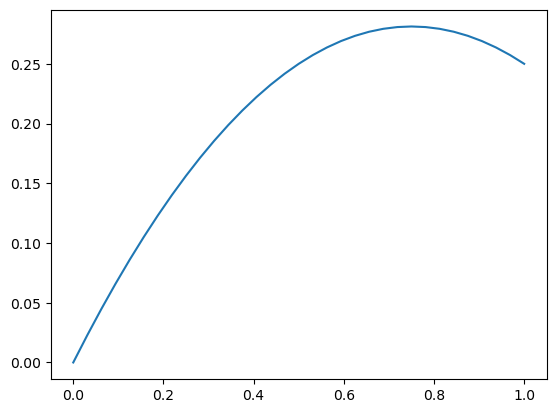

In [ ]:
"""This demo program solves Poisson's equation in 1-D
    - d^2 u/ dx^2  = f(x)
on the unit interval with source f given by
    f(x) = 1
and boundary conditions given by
    u(0)= 0        for x = 0 
    du/dx = alpha for x=1
"""  # Dokumentasi: menyelesaikan Poisson 1D dengan f=1, u(0)=0, du/dx(1)=alpha

# Modified from demo_poisson.py from the FEniCS demos  # Dimodifikasi dari demo FEniCS

# Begin demo  # Awal demo

from dolfin import *  # Impor FEniCS

# Create mesh and define function space
mesh = UnitIntervalMesh(32)  # Mesh interval unit dengan 32 elemen
V = FunctionSpace(mesh, "Lagrange", 1)  # Ruang fungsi Lagrange orde 1

# Define Dirichlet boundary (x = 0 )
def boundary(x):  # Fungsi batas Dirichlet hanya di x=0
    return x[0] < DOLFIN_EPS  # True jika x dekat 0

# Define boundary condition
# Dirichlet
u0 = Constant(0.0)  # Nilai batas u=0
bc = DirichletBC(V, u0, boundary)  # Kondisi batas Dirichlet
# Neumann:  du/dx = \alpha
alpha=Constant(-.25)  # Nilai alpha untuk kondisi Neumann

# Define variational problem
u = TrialFunction(V)  # Trial function
v = TestFunction(V)  # Test function
f = Constant(1.)  # Sumber f=1
a = v.dx(0)*u.dx(0)*dx  # Bentuk bilinear
L = v*f*dx + v*alpha*ds  # Bentuk linear dengan term Neumann

# Compute solution
u = Function(V)  # Objek solusi
solve(a == L, u, bc)  # Selesaikan

# Save solution in VTK format
file = File("poisson.pvd")  # File output
file << u  # Simpan

# Plot solution
#plot(u, interactive=True)  # Plot interaktif (dikomentari)
plot(u)  # Plot solusi

<div style="text-align: justify; font-family: 'Times New Roman', Times, serif;">

## Elemen Hingga di Dimensi yang Lebih Tinggi

Salah satu keindahan FEniCS adalah kemampuannya untuk menulis dan menyelesaikan PDE berdimensi tinggi dengan usaha yang hampir sama seperti masalah 1-D. Sebagai contoh, kita akan mempertimbangkan masalah berikut dan implementasi FEniCSnya.

### Bentuk Kuat

Selesaikan masalah Poisson umum pada persegi panjang

$$
    -\nabla\cdot \alpha(x)\nabla u = f(x) \quad \mathrm{on} \quad \Omega=[0,2]\times[0,1]
$$

di mana $\alpha(x,y) > 0$ pada $\Omega$ ($\alpha=1$ adalah Poisson biasa) dan suku sumber 

$$
    f(\boldsymbol{x}) = 10 \exp\left[ -((x - 1)^2 + (y - 1/2)^2)/0.02\right]
$$ 

dengan kondisi batas Dirichlet dalam arah x
$$
    u(0,y) = u(2,y) =0
$$

dan kondisi batas Aliran Neumann pada batas y
$$
    \alpha(x)\nabla u\cdot\hat{n} = \sin(5x) \quad \mathrm{on} \quad y=0,1
$$
 
### Bentuk Lemah

Untuk membentuk bentuk lemah, kita memilih ruang fungsi $\cal V$, misalnya fungsi linear piecewise di atas segitiga, dan menyelesaikan masalah variasional,  

> Temukan $u$ dalam $\cal V$ sehingga 

$$ 
    -\int_\Omega v\nabla\cdot \alpha\nabla u dx = \int_\Omega vf dx
$$
untuk semua $v$ dalam $\cal V$.

Sekali lagi, integrasi masalah bilinear menurut bagian memberikan

\begin{align}
    -\int_\Omega v\nabla\cdot (\alpha \nabla u) dx &= \int_\Omega \nabla v\cdot (\alpha \nabla u) dx - \int_\Omega \nabla\cdot v(\alpha\nabla u) dx \\
    & = \int_\Omega \nabla v\cdot (\alpha \nabla u) dx - \int_{\partial\Omega}  v (\alpha\nabla u\cdot\hat{n}) ds \\
\end{align}

di mana kita telah menerapkan teorema divergensi Gauss pada suku terakhir untuk memindahkan integral ke batas di mana kita mengetahui BC Neumann.

Dalam bahasa bentuk variasional, bentuk lemah dapat digambarkan sebagai $a(u,v) = L(v)$ di mana

\begin{align}
    a(u,v) &= \int_\Omega \nabla v\cdot \alpha \nabla u dx \\
    L(v) &= \int_\Omega vf dx + \int_{\partial\Omega}  v g ds \\
\end{align}

di mana 

$$
    g(x,y) = \alpha\nabla u\cdot\hat{n} = \sin(5x)
$$

Luar biasa, kode FEniCS untuk masalah ini terlihat sangat mirip dengan apa yang baru saja kita tulis.


In [ ]:
"""This demo program solves Poisson's equation
    - div alpha(x,y) grad u(x, y) = f(x, y)
on the a rectangular domain [0,2]x[0,1] with source f given by
    f(x, y) = 10*exp(-((x - 0.5)^2 + (y - 0.5)^2) / 0.02)
and boundary conditions given by
    u(x, y) = 0        for x = 0 or x = 2
alpha\grad u . n (x,y) = sin(5*x) for y = 0 or y = 1
"""  # Dokumentasi: Poisson 2D dengan koefisien alpha, sumber Gaussian, BC campuran

# modified from Dolfin Poisson demo_poisson.py  # Dimodifikasi dari demo DOLFIN

# Copyright (C) 2007-2011 Anders Logg  # Lisensi

# This file is part of DOLFIN.  # Bagian dari DOLFIN

# DOLFIN is free software: you can redistribute it and/or modify  # Lisensi LGPL

# it under the terms of the GNU Lesser General Public License as published by

# the Free Software Foundation, either version 3 of the License, or

# (at your option) any later version.

# DOLFIN is distributed in the hope that it will be useful,

# but WITHOUT ANY WARRANTY; without even the implied warranty of

# MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. See the

# GNU Lesser General Public License for more details.

# You should have received a copy of the GNU Lesser General Public License

# along with DOLFIN. If not, see <http://www.gnu.org/licenses/>.

# First added:  2007-08-16

# Last changed: 2012-11-12

# Begin demo  # Awal demo

from dolfin import *  # Impor FEniCS

# Create mesh and define function space
mesh = RectangleMesh(0.,0.,2.,1.,64, 32,)  # Mesh persegi panjang [0,2]x[0,1] dengan 64x32 elemen
V = FunctionSpace(mesh, "Lagrange", 1)  # Ruang fungsi Lagrange orde 1

# Define Dirichlet boundary (x = 0 or x = 2)
def boundary(x):  # Fungsi batas Dirichlet di x=0 dan x=2
    return x[0] < DOLFIN_EPS or x[0] > 2.0 - DOLFIN_EPS  # True jika x dekat 0 atau 2

# Define boundary condition
u0 = Constant(0.0)  # Nilai batas u=0
bc = DirichletBC(V, u0, boundary)  # Kondisi batas Dirichlet

# Define variational problem
u = TrialFunction(V)  # Trial function
v = TestFunction(V)  # Test function
alpha = Constant(1.)  # Koefisien alpha=1
#a = Expression("1. + 0.5*sin(8*x[0])*sin(4*x[1])")  # Ekspresi alpha (dikomentari)
f = Expression("10*exp(-(pow(x[0] - 0.5, 2) + pow(x[1] - 0.5, 2)) / 0.02)")  # Sumber f: Gaussian di (0.5,0.5)
g = Expression("sin(5*x[0])")  # Fungsi g untuk BC Neumann
a = inner(grad(v),alpha*grad(u))*dx  # Bentuk bilinear untuk -div(alpha grad u)
L = v*f*dx + v*g*ds  # Bentuk linear dengan sumber dan BC Neumann

# Compute solution
u = Function(V)  # Objek solusi
solve(a == L, u, bc)  # Selesaikan

# Save solution in VTK format
file = File("poisson.pvd")  # File output
file << u  # Simpan

# Plot solution
plot(u, interactive=False)  # Plot solusi tanpa interaktif

TypeError: __init__(): incompatible constructor arguments. The following argument types are supported:
    1. dolfin.cpp.generation.RectangleMesh(p0: dolfin::Point, p1: dolfin::Point, nx: int, ny: int, diagonal: str = 'right')
    2. dolfin.cpp.generation.RectangleMesh(comm: MPICommWrapper, p0: dolfin::Point, p1: dolfin::Point, nx: int, ny: int, diagonal: str = 'right')

Invoked with: 0.0, 0.0, 2.0, 1.0, 64, 32

<div style="text-align: justify; font-family: 'Times New Roman', Times, serif;">

# Perangkat Lunak Lainnya

### Sumber Terbuka
- TerraFERMA
- FEAP
- ...

### Komersial
- Abaqus
- Comsol
- ...

<div style="text-align: justify; font-family: 'Times New Roman', Times, serif;">

# Maju dan Ke Atas dengan MEH: daftar yang tidak lengkap

- Menambahkan ketergantungan waktu
- Elemen eksotis
- Stabilitas pilihan elemen
- Persamaan hiperbolik dan parabolik
- Persamaan non-linear
- Pilihan pemecah yang efektif
- Multi-fisika
- dan seterusnya